# Music Classificator

This notebook trains a **guitar macro-genre classifier** on GPU-friendly log-mel spectrograms.

- **Dataset & preprocessing**
  - Source audio loops are grouped into a small set of **macro-genres** (e.g. `funk_disco`, `rock_blues`, `hip_hop_trap`).
  - Each `.wav` file is normalized, **augmented** (gain, noise, simple EQ), and converted into a **Mel spectrogram** (`N_MELS=256`, `SR=44.1 kHz`).
  - Spectrograms are cached as `.npy` files and indexed in `index.json` for fast loading.

- **Input pipeline**
  - During training, each sample is a **time crop** of the mel spectrogram.
  - Light on-the-fly augmentation is applied on the spectrogram (time/freq masking + pooling) to improve robustness.
  - Data is split with **stratified train/validation** to preserve class balance.

- **Model**
  - The classifier is a **ResMelNet** CNN:
    - convolutional stem + several **ResBlocks** with SE attention,
    - global pooling and a small fully-connected head for classification.
  - Implemented in PyTorch and moved to `cuda` / `mps` / `cpu` depending on availability.

- **Training loop**
  - Optimizer: **AdamW** with cosine-annealing learning-rate schedule.
  - Loss: **label-smoothed cross-entropy** (`LSCELoss`) for more stable training.
  - Mixed precision and gradient accumulation are used when on GPU.
  - At each epoch we track **training loss** and **validation accuracy**, saving the best model checkpoint.

- **Results**
  - The final training curves show steadily decreasing loss and rising validation accuracy,
    indicating a well-behaved training process and a model that learns to separate macro-genres
    from their mel-spectrogram representations.

### Load shared configuration

Import:
- **sys** – used to modify `sys.path` so Python can see the `python/` folder as a module directory.  
- **pathlib.Path** – builds OS-independent paths to locate the project root and the `python/` directory.  
- **from header import \*** – pulls in all shared config from `python/header.py` (device setup, data paths, hyperparameters).

Constants (imported from `header.py` and printed here):
- **DEVICE** – selected compute device (`cuda`, `mps`, or `cpu`).  
- **CLASSES** – tuple of macro-genre names used as classification targets.  
- **ITEMS** – list of dataset entries, each with mel path, class index, and metadata.  
- **T_SEC** – audio duration (in seconds) for each training crop.  
- **TIME_D** / **FREQ_D** – temporal and frequency downsampling factors (avg-pool).  
- **BATC_S** – batch size used by the DataLoader.  
- **ACC_ST** – gradient accumulation steps before each optimizer update.  
- **LR** – learning rate for the optimizer.  
- **PATIEN** – early-stopping patience in epochs without val-accuracy improvement.  
- **NUM_WORKERS** – number of DataLoader worker processes.  
- **PIN_MEMORY** – whether DataLoader uses pinned memory (for faster GPU transfer).

In [1]:
import sys
from pathlib import Path

project_root = Path("..").resolve()
python_dir = project_root / "python"      

sys.path.append(str(python_dir))

from header import *

print(f"Using {DEVICE} | classes={len(CLASSES)} | items={len(ITEMS)}")
print(
    f"T_SEC={T_SEC}, TIME_D={TIME_D}, FREQ_D={FREQ_D}, BATC_S={BATC_S}, "
    f"ACC_ST={ACC_ST}, LR={LR}, PATIEN={PATIEN}, NUM_WORKERS={NUM_WORKERS}"
)

Using mps | classes=8 | items=8022
T_SEC=6.0, TIME_D=12, FREQ_D=4, BATC_S=6, ACC_ST=2, LR=0.0005, PATIEN=12, NUM_WORKERS=0


### Train/validation split and DataLoaders

This cell prepares the data pipeline for training:

- **Stratified split**
  - `labels = [it["class_idx"] for it in ITEMS]` collects one label per item.
  - `StratifiedShuffleSplit(...)` creates a single split (`n_splits=1`) with **20%** of the data for validation, preserving the class distribution.
  - `tr_idx`, `va_idx` are index lists used to build `train_items` and `val_items`.

- **Datasets**
  - `MelDataset(train_items, train=True)` enables random crops and on-the-fly augmentation.
  - `MelDataset(val_items, train=False)` uses deterministic center crops (no augmentation).

- **DataLoaders**
  - `trL` and `vaL` wrap the datasets into mini-batches:
    - `batch_size = BATC_S`
    - `shuffle=True` for training, `False` for validation
    - `num_workers = NUM_WORKERS` controls parallel loading
    - `pin_memory = PIN_MEMORY` speeds up GPU transfers when enabled.

Finally, a single sample from `tr_ds` is printed to confirm the **input shape** seen by the CNN.

In [2]:
labels = [it["class_idx"] for it in ITEMS]
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
(tr_idx, va_idx), = sss.split(np.zeros(len(labels)), labels)

train_items = [ITEMS[i] for i in tr_idx]
val_items   = [ITEMS[i] for i in va_idx]

tr_ds = MelDataset(train_items, train=True)
va_ds = MelDataset(val_items,   train=False)

trL = DataLoader(
    tr_ds,
    batch_size=BATC_S,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)
vaL = DataLoader(
    va_ds,
    batch_size=BATC_S,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

sample_in, _ = tr_ds[0]
print("Input patch shape to CNN:", tuple(sample_in.shape))

Input patch shape to CNN: (1, 64, 86)


### Model creation and parameter count

This cell instantiates and prepares the classifier:

- `model = ResMelNet(n_classes=len(CLASSES)).to(DEVICE)`  
  Builds the **ResMelNet** CNN with `n_classes` equal to the number of macro-genres and moves it to the selected device (CPU / CUDA / MPS).

- `torch.compile(model, mode="reduce-overhead")` (only on CUDA)  
  Wraps the model with PyTorch 2.x compilation to slightly optimize execution and reduce Python overhead during training.

- `n_params = sum(...)`  
  Counts all **trainable parameters** (those with `requires_grad=True`) and prints the total in millions (`M`) to get a quick sense of model size and capacity.

In [3]:
model = ResMelNet(n_classes=len(CLASSES)).to(DEVICE)
if DEVICE_TYPE == "cuda":
    model = torch.compile(model, mode="reduce-overhead")

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model params: {n_params/1e6:.2f}M")

Model params: 6.58M


### Training loop, optimization, and checkpointing

This cell defines the **optimizer**, **scheduler**, **loss**, and runs the full training/validation loop:

- **Setup**
  - `opt = torch.optim.AdamW(...)` — AdamW optimizer for all model parameters with learning rate `LR` and weight decay `WD`.
  - `sched = CosineAnnealingWarmRestarts(...)` — cosine LR schedule with periodic warm restarts to help convergence.
  - `lossf = LSCELoss(LAB_SM)` — cross-entropy loss with label smoothing factor `LAB_SM`.
  - `GradScaler / autocast` on CUDA — enables mixed-precision training for faster and more memory-efficient training on GPU.
  - `hist = {"tr_loss": [], "va_acc": []}` — stores training loss and validation accuracy over epochs.

- **Training loop (per epoch)**
  - Sets `model.train()`, zeroes the gradients, and iterates over the training DataLoader `trL`.
  - For each mini-batch: moves data to `DEVICE`, runs forward pass under `autocast_ctx`, computes loss, backpropagates (with gradient accumulation over `ACC_ST` steps), and performs an optimizer step.
  - Tracks and averages training loss (`tr_loss`) for the epoch and steps the LR scheduler.

- **Validation loop**
  - Switches to `model.eval()` and disables gradients.
  - Iterates over `vaL`, computes predictions, and measures **validation accuracy** `acc`.
  - Appends `tr_loss` and `acc` to `hist` and prints a summary line for the epoch.

- **Checkpointing & early stopping**
  - If the new `val_acc` is better than `best_acc`, saves a checkpoint to `CHECKPOINTS/guitar_macro_classifier.pth` containing the model weights and class list.
  - If there is no improvement for `PATIEN` consecutive epochs, stops training early.
  - At the end, prints the best validation accuracy reached.

In [4]:
opt   = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WD)
sched = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(opt, T_0=4, T_mult=2)
lossf = LSCELoss(LAB_SM)

if DEVICE_TYPE == "cuda":
    scaler = amp.GradScaler(enabled=True)
else:
    scaler = None

best_acc = 0.0
noimp = 0
hist = {"tr_loss": [], "va_acc": []}

for ep in range(EPOCHS):
    model.train()
    run, steps = 0.0, 0
    opt.zero_grad(set_to_none=True)

    if DEVICE_TYPE == "cuda":
        autocast_ctx = amp.autocast(device_type="cuda", dtype=torch.float16)
    else:
        autocast_ctx = nullcontext()

    train_bar = tqdm(
        total=len(trL),
        desc=f"Train epoch {ep+1}/{EPOCHS}",
        mininterval=0.5,
        leave=False
    )
    for step, (X, y) in enumerate(trL, 1):
        X = X.to(DEVICE, non_blocking=True)
        y = torch.as_tensor(y, device=DEVICE)

        with autocast_ctx:
            logits = model(X)
            loss = lossf(logits, y) / ACC_ST

        if DEVICE_TYPE == "cuda":
            scaler.scale(loss).backward()
        else:
            loss.backward()

        if step % ACC_ST == 0:
            if DEVICE_TYPE == "cuda":
                scaler.step(opt)
                scaler.update()
            else:
                opt.step()
            opt.zero_grad(set_to_none=True)

        run += loss.item() * ACC_ST
        steps += 1
        train_bar.update(1)
    train_bar.close()

    tr_loss = run / max(1, steps)
    sched.step(ep + 1)
    hist["tr_loss"].append(tr_loss)

    model.eval()
    correct = n = 0
    y_true, y_pred = [], []

    val_bar = tqdm(
        total=len(vaL),
        desc=f"Valid epoch {ep+1}/{EPOCHS}",
        mininterval=0.5,
        leave=False
    )
    with torch.no_grad():
        for X, y in vaL:
            X = X.to(DEVICE, non_blocking=True)
            y = torch.as_tensor(y, device=DEVICE)
            p = model(X).argmax(1)
            correct += (p == y).sum().item()
            n += y.numel()
            y_true += y.tolist()
            y_pred += p.tolist()
            val_bar.update(1)
    val_bar.close()

    acc = correct / max(1, n)
    hist["va_acc"].append(acc)
    print(f"[Epoch {ep+1:02d}] train_loss={tr_loss:.4f} | val_acc={acc:.3f}")

    if acc > best_acc:
        best_acc, noimp = acc, 0
        os.makedirs(CHECKPOINTS, exist_ok=True)
        torch.save(
            {"model": model.state_dict(), "classes": CLASSES},
            f"{CHECKPOINTS}/guitar_macro_classifier.pth"
        )
        print(f"Saved new best model — val_acc={best_acc:.3f}")
    else:
        noimp += 1
        if noimp >= PATIEN:
            print("Early stopping.")
            break

print("Best val_acc:", round(best_acc, 3))

[Epoch 01] train_loss=1.8250 | val_acc=0.370
Saved new best model — val_acc=0.370


[Epoch 02] train_loss=1.7920 | val_acc=0.376
Saved new best model — val_acc=0.376


[Epoch 03] train_loss=1.7622 | val_acc=0.415
Saved new best model — val_acc=0.415


[Epoch 04] train_loss=1.7334 | val_acc=0.425
Saved new best model — val_acc=0.425


[Epoch 05] train_loss=1.7603 | val_acc=0.426
Saved new best model — val_acc=0.426


...

[Epoch 46] train_loss=0.7254 | val_acc=0.918
Saved new best model — val_acc=0.918


[Epoch 47] train_loss=0.7136 | val_acc=0.907


[Epoch 48] train_loss=0.6873 | val_acc=0.919
Saved new best model — val_acc=0.919


[Epoch 49] train_loss=0.6845 | val_acc=0.935
Saved new best model — val_acc=0.935


[Epoch 50] train_loss=0.6530 | val_acc=0.942
Saved new best model — val_acc=0.942
Best val_acc: 0.942


### Plot training curves

This cell visualizes the training progress:

- Creates a Matplotlib figure with two y-axes sharing the same x-axis (epochs).
- Plots **training loss** (`hist["tr_loss"]`) on the left y-axis.
- Plots **validation accuracy** (`hist["va_acc"]`) on the right y-axis as a dashed green line.
- Adds grid, labels, combined legend, and a title *"Training curves"*.

The resulting plot makes it easy to see how loss decreases and accuracy increases (or overfits) across epochs.

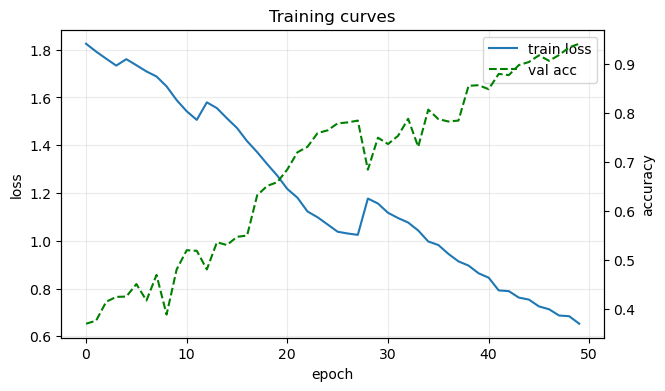

In [5]:
fig, ax1 = plt.subplots(figsize=(7,4))
ax1.plot(hist["tr_loss"], label="train loss")
ax1.set_xlabel("epoch"); ax1.set_ylabel("loss")
ax2 = ax1.twinx()
ax2.plot(hist["va_acc"], "g--", label="val acc")
ax2.set_ylabel("accuracy")
ax1.grid(True, alpha=0.25)
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines+lines2, labels+labels2, loc="best")
plt.title("Training curves")
plt.show()

### Training curves overview

This plot shows how the model improves over time:

- **Training loss** (blue) steadily decreases, indicating better fitting.
- **Validation accuracy** (green dashed) rises across epochs, showing improved generalization.
- The dual-axis visualization clearly highlights the relationship between loss reduction and accuracy gain.

Overall, the model converges smoothly with no signs of early overfitting.